In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "C:\\Users\\brand\\Downloads\\"

MOE_df = pd.read_csv(path + "MOE.csv")
transformer_df = pd.read_csv(path + "Transformer.csv")

In [3]:
columns = ['Time', 'AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1', 'PA-F1', 'Event-based-F1', 'R-based-F1', 'Affiliation-F']
all_models = [transformer_df, MOE_df]

# 3. Create a matching list of names for labeling
model_names = ['Transformer', 'Moe']

summary_list = []

for df, name in zip(all_models, model_names):
    # Calculate the mean of the metrics for this model
    means = df[columns].mean()
    means.name = name  # Set the name of the row to the model name
    summary_list.append(means)

# Combine into one dataframe
comparison_table = pd.concat(summary_list, axis=1).T

print("\n\n--- Transformer vs. MOE TABLE (AVERAGES) ---")
# Adjust pandas settings to ensure the whole table prints
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(comparison_table.round(4))



--- Transformer vs. MOE TABLE (AVERAGES) ---
                 Time  AUC-PR  AUC-ROC  VUS-PR  VUS-ROC  Standard-F1   PA-F1  Event-based-F1  R-based-F1  Affiliation-F
Transformer   66.3299   0.062   0.8690  0.0487   0.7613       0.1665  0.3622          0.1617      0.1994         0.7603
Moe          159.1981   0.074   0.8896  0.0579   0.8141       0.1813  0.3971          0.1757      0.1881         0.7862


In [4]:
# 1. Extract the source name into a permanent column
transformer_df['source'] = transformer_df['file'].str.extract(r'\d+_([a-zA-Z]+)')

# 2. Split into a dictionary: keys are 'Genesis', 'NASA', etc.
# values are the corresponding dataframes
transformer_groups = {name: group for name, group in transformer_df.groupby('source')}


# 1. Extract the source name into a permanent column
MOE_df['source'] = MOE_df['file'].str.extract(r'\d+_([a-zA-Z]+)')

# 2. Split into a dictionary: keys are 'Genesis', 'NASA', etc.
# values are the corresponding dataframes
MOE_groups = {name: group for name, group in MOE_df.groupby('source')}

In [7]:
MOE_groups.keys()

dict_keys(['MixedRegimes'])

In [9]:
# Define your metrics
columns = ['Time', 'AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1', 'PA-F1', 'Event-based-F1', 'R-based-F1', 'Affiliation-F']
datasets = ['MixedRegimes']

summary_data = []

for ds in datasets:
    # Safely get the dataframes from your dictionaries
    # (Assumes transformer_groups and MOE_groups are dicts keyed by dataset name)
    df_trans = transformer_groups.get(ds)
    df_moe = MOE_groups.get(ds)
    
    # Skip if the dataset is missing in either model's results
    if df_trans is None or df_moe is None:
        continue

    # 1. Calculate Averages for both for this dataset
    mean_trans = df_trans[columns].mean()
    mean_moe = df_moe[columns].mean()

    # 2. Calculate Deltas (MoE - Transformer)
    # Positive means MoE performed better
    auc_roc_delta = mean_moe['AUC-ROC'] - mean_trans['AUC-ROC']
    vus_pr_delta = mean_moe['VUS-PR'] - mean_trans['VUS-PR']
    Event_F1_delta = mean_moe['Event-based-F1'] - mean_trans['Event-based-F1']
    VUS_ROC_Delta = mean_moe['VUS-ROC'] - mean_trans['VUS-ROC']
    
    # 3. Efficiency Loss (Relative increase in time)
    # (MoE_Time / Trans_Time) - 1. E.g., 0.36 means MoE is 36% slower.
    eff_loss = ((mean_trans['Time'] / mean_moe['Time']) - 1) * 100

    # Store results in a flat dictionary
    summary_data.append({
        'Dataset': ds,
        'AUC-ROC_Delta': auc_roc_delta,
        'VUS-PR_Delta': vus_pr_delta,
        'VUS-ROC_Delta': VUS_ROC_Delta,
        'Event_F1_Delta': Event_F1_delta,
        'Efficiency_Loss': eff_loss,
        'Trans_Time': mean_trans['Time'],
        'MoE_Time': mean_moe['Time']
    })

# Create the final dataframe
comparison_table = pd.DataFrame(summary_data).set_index('Dataset')

print("\n--- Granular Performance Comparison ---")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(comparison_table.round(4))


--- Granular Performance Comparison ---
              AUC-ROC_Delta  VUS-PR_Delta  VUS-ROC_Delta  Event_F1_Delta  Efficiency_Loss  Trans_Time  MoE_Time
Dataset                                                                                                        
MixedRegimes         0.0207        0.0092         0.0528           0.014          -58.335     66.3299  159.1981


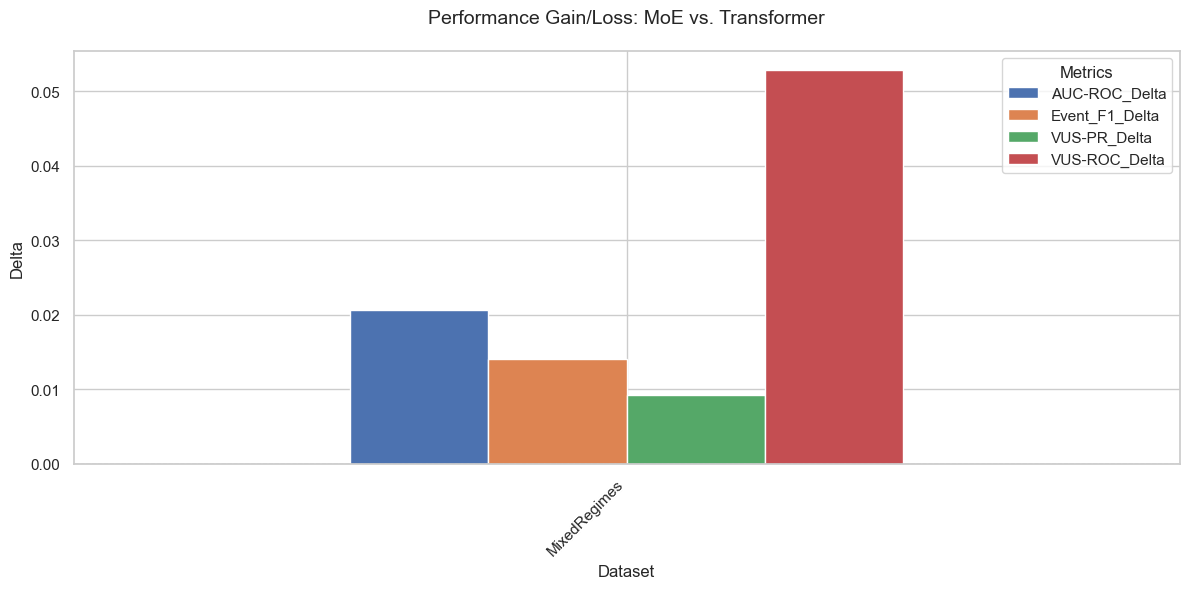

<Figure size 1200x500 with 0 Axes>

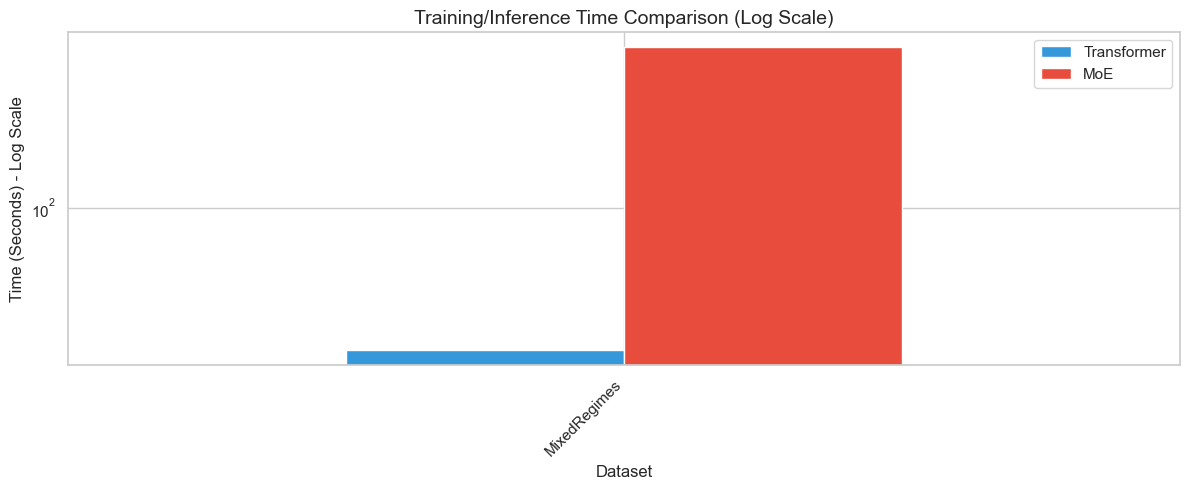

In [10]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# 1. Performance Deltas across Datasets
# Shows exactly where MoE improves performance vs where it might degrade it
fig, ax1 = plt.subplots(figsize=(12, 6))

# We'll plot AUC-ROC Delta and Event-F1 Delta
comparison_table[['AUC-ROC_Delta', 'Event_F1_Delta', 'VUS-PR_Delta', 'VUS-ROC_Delta']].plot(kind='bar', ax=ax1)
ax1.set_title('Performance Gain/Loss: MoE vs. Transformer', fontsize=14, pad=20)
ax1.set_ylabel('Delta')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics')
plt.tight_layout()
plt.savefig('performance_deltas.png')

# 3. Direct Runtime Comparison (Log Scale)
# Useful if some datasets take seconds and others take hours
plt.figure(figsize=(12, 5))
comparison_table[['Trans_Time', 'MoE_Time']].plot(kind='bar', logy=True, figsize=(12,5), color=['#3498db', '#e74c3c'])
plt.title('Training/Inference Time Comparison (Log Scale)', fontsize=14)
plt.ylabel('Time (Seconds) - Log Scale')
plt.xticks(rotation=45, ha='right')
plt.legend(['Transformer', 'MoE'])
plt.tight_layout()
plt.savefig('time_comparison.png')